# Cell 1: Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Cell 2: Upload Dataset

In [6]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train (1).csv


# Cell 3: Load Dataset

In [7]:
df = pd.read_csv('train.csv')

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


# Cell 4: Basic EDA

In [8]:
print("Shape of Dataset:")
print(df.shape)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistics:")
print(df.describe())

Shape of Dataset:
(891, 12)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare    

# Cell 5: Visualizations

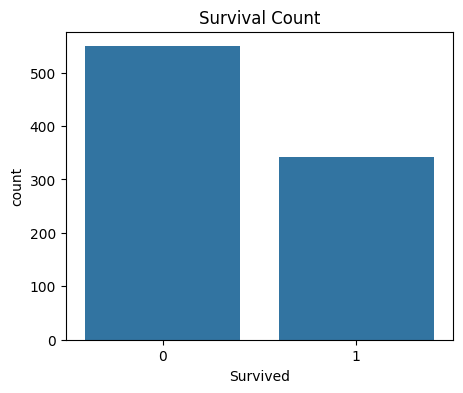

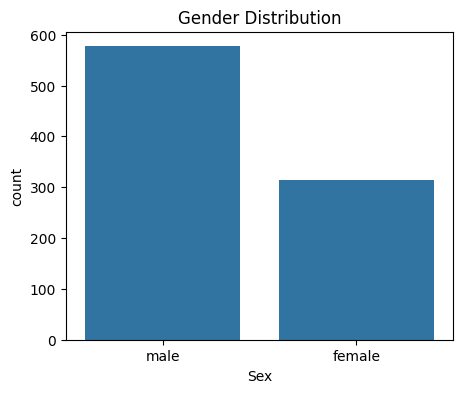

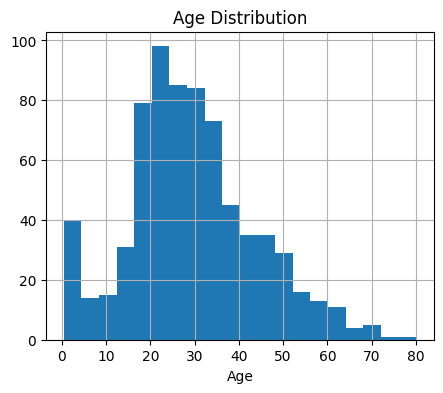

In [9]:
plt.figure(figsize=(5,4))
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.show()

plt.figure(figsize=(5,4))
sns.countplot(x='Sex', data=df)
plt.title('Gender Distribution')
plt.show()

plt.figure(figsize=(5,4))
df['Age'].hist(bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()

# Cell 6: Handle Missing Values

In [10]:
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# Cell 7: Feature Engineering

In [11]:
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])

df['Embarked'] = le.fit_transform(df['Embarked'])

# Cell 8: Select Features and Target

In [12]:
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

y = df['Survived']

# Cell 9: Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(712, 7)
(179, 7)


# Cell 10: Logistic Regression

In [14]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, pred_lr))

Logistic Regression Accuracy:
0.8100558659217877


# Cell 11: Random Forest

In [15]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:")
print(accuracy_score(y_test, pred_rf))

Random Forest Accuracy:
0.8212290502793296


# Cell 12: Model Comparison

In [16]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, pred_lr))

print("Random Forest Accuracy:",
      accuracy_score(y_test, pred_rf))

Logistic Regression Accuracy: 0.8100558659217877
Random Forest Accuracy: 0.8212290502793296


# Cell 13: Precision, Recall, F1-Score

In [17]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



# Cell 14: Confusion Matrix

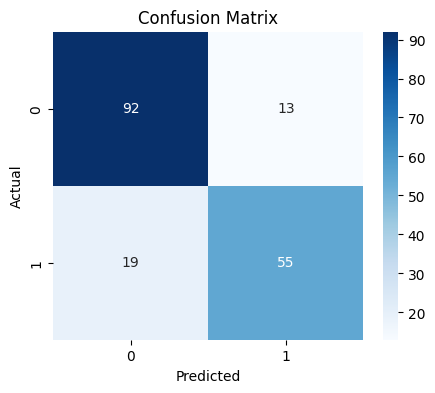

In [18]:
cm = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Cell 15: Feature Importance:

    Feature  Importance
1       Sex    0.271410
5      Fare    0.265010
2       Age    0.249995
0    Pclass    0.086957
3     SibSp    0.053685
4     Parch    0.039897
6  Embarked    0.033044


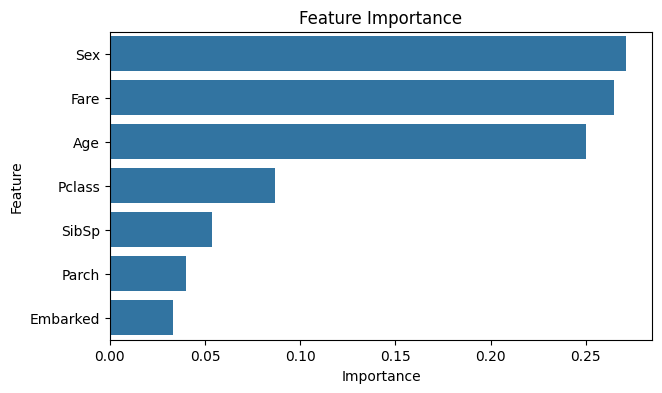

In [19]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

plt.figure(figsize=(7,4))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)
plt.title('Feature Importance')
plt.show()